# TimeGAN v3 — Corrección estructural

## Diagnóstico de las versiones anteriores

El problema no eran los hiperparámetros. Era el ratio datos/dimensiones:

| Versión | Ventanas | feature_dim | Ratio | Batches/época | Resultado |
|---------|----------|-------------|-------|---------------|-----------|
| v0 (stride=1) | ~19k | 114 | 167 | ~150 | G colapsado |
| v1 (stride=20) | 948 | 114 | 8.3 | **7** | **Memorización** |
| v2 (stride=20) | 948 | 114 | 8.3 | **7** | **AUC=1.0** |
| **v3 (stride=5, solo cont.)** | ~3800 | **23** | 165 | ~30 | **Objetivo** |

## Los 3 cambios estructurales de esta versión

1. **Solo continuas para TimeGAN** — `feature_dim` baja de 114 a 23. Las discretas (one-hot) son variables binarias que el GRU no puede modelar bien como secuencia temporal. Se sintetizan por separado con estadísticas empíricas.
2. **stride=5 para TimeGAN** — de 948 a ~3800 ventanas. Suficiente solapamiento para coherencia temporal, suficiente diversidad para generalizar.
3. **eta=1, lambda_m=0** — con un dataset adecuado, la señal adversarial pura es suficiente. El moment matching con pocos datos destruye el balance G/D.


In [1]:
import os
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


## Cargar configuración


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]

# V3: stride=5 para TimeGAN → balance diversidad/coherencia
# Con stride=5 y ventanas de 60: solapamiento 92% pero ~4x más datos que stride=20
TIMEGAN_STRIDE = 5

print(f"Window size: {WINDOW_SIZE}")
print(f"Stride detector: {STRIDE_DETECTOR}")
print(f"Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"Continuous cols: {len(continuous_cols)}")
print(f"Discrete cols: {len(discrete_cols)}")
print(f"feature_dim para TimeGAN v3: {len(continuous_cols)} (solo continuas)")


Window size: 60
Stride detector: 1
Stride TimeGAN: 5
Continuous cols: 23
Discrete cols: 26
feature_dim para TimeGAN v3: 23 (solo continuas)


## Cargar y preparar datos


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"
file_paths = sorted(clean_folder.glob("*.csv"))

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in file_paths}
print("Archivos:", list(files.keys()))


Archivos: ['22June2020_1', '22June2020_2', '29June2020_1', '29June2020_2']


In [5]:
common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {name: df[common_cols].copy() for name, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")

continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
print(f"Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}")


Continuas: 23 | Discretas: 26


In [6]:
def remove_warmup(df, warmup_seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    start_time = df["t_stamp"].min()
    return df[df["t_stamp"] >= start_time + pd.Timedelta(seconds=warmup_seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], warmup_seconds=WARMUP)


## Split temporal


In [7]:
def temporal_split(df, train_ratio=0.6, val_ratio=0.2):
    n = len(df)
    t1 = int(n * train_ratio)
    t2 = int(n * (train_ratio + val_ratio))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df_i in files.items():
    df_base = df_i[["t_stamp"] + feature_cols].copy()
    tr, va, te = temporal_split(df_base)
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={tr.shape}, val={va.shape}, test={te.shape}")


22June2020_1: train=(8568, 50), val=(2856, 50), test=(2856, 50)
22June2020_2: train=(2088, 50), val=(696, 50), test=(696, 50)
29June2020_1: train=(4248, 50), val=(1416, 50), test=(1417, 50)
29June2020_2: train=(4248, 50), val=(1416, 50), test=(1416, 50)


## Escalado


In [8]:
scaler_cont_detector = StandardScaler()
scaler_cont_timegan  = MinMaxScaler()

train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)
scaler_cont_timegan.fit(train_all_cont)
print("Scalers fitted.")


Scalers fitted.


In [9]:
scaled_cont_by_file = {}
raw_disc_by_file    = {}

for name in split_by_file:
    scaled_cont_by_file[name] = {}
    raw_disc_by_file[name]    = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_cont_by_file[name][subset] = pd.DataFrame(
            scaler_cont_timegan.transform(df_part[continuous_cols]),
            columns=continuous_cols, index=df_part.index
        )
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


## Catálogo discretas y distribuciones empíricas

**V3: Las discretas NO se modelan con TimeGAN.**  
El GRU trata los one-hot como señales continuas y genera valores intermedios  
como 0.3 o 0.7 en lugar de 0 o 1. Esto añade 91 dimensiones de ruido que  
impiden que el modelo aprenda la estructura de las 23 continuas.  

En su lugar, se sintetizan muestreando de la distribución empírica de cada  
variable discreta en el conjunto de entrenamiento. Esto es más fiel a la  
realidad para variables binarias de control (válvulas, bombas).


In [10]:
# Catálogo de valores y frecuencias para síntesis empírica
disc_empirical = {}  # col -> {value: prob}

train_disc_global = pd.concat(
    [raw_disc_by_file[name]["train"] for name in raw_disc_by_file], axis=0
).reset_index(drop=True)

for col in discrete_cols:
    vc = train_disc_global[col].value_counts(normalize=True)
    disc_empirical[col] = dict(vc)

# También para one-hot (para compatibilidad con detector)
discrete_value_maps = {
    col: sorted(train_disc_global[col].dropna().unique().tolist())
    for col in discrete_cols
}
onehot_sizes = {col: len(discrete_value_maps[col]) for col in discrete_cols}
total_disc_onehot_dim = sum(onehot_sizes.values())

print(f"Total one-hot dim discretas: {total_disc_onehot_dim}")
print(f"feature_dim que verá TimeGAN: {len(continuous_cols)} (solo continuas)")


Total one-hot dim discretas: 91
feature_dim que verá TimeGAN: 23 (solo continuas)


## Construcción de ventanas — solo continuas para TimeGAN

**Stride=5**: Con window_size=60, stride=5 produce ~4x más ventanas que stride=20  
con un solapamiento de 55/60 timesteps. Esto es suficiente para que el modelo  
aprenda la autocorrelación temporal sin memorizar ejemplos específicos.


In [11]:
def build_cont_windows(
    scaled_cont_by_file, subset, window_size=60, stride=5
):
    windows, origins = [], []
    for name in scaled_cont_by_file:
        arr = scaled_cont_by_file[name][subset].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i+window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins


In [12]:
train_cont_windows, train_origin = build_cont_windows(scaled_cont_by_file, "train", WINDOW_SIZE, TIMEGAN_STRIDE)
val_cont_windows,   val_origin   = build_cont_windows(scaled_cont_by_file, "val",   WINDOW_SIZE, TIMEGAN_STRIDE)
test_cont_windows,  test_origin  = build_cont_windows(scaled_cont_by_file, "test",  WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_cont_windows.shape}  ({len(train_cont_windows)} ventanas)")
print(f"Val:   {val_cont_windows.shape}")
print(f"Test:  {test_cont_windows.shape}")
print(f"\nMin/Max train: {train_cont_windows.min():.4f} / {train_cont_windows.max():.4f}")


Train: (3784, 60, 23)  (3784 ventanas)
Val:   (1232, 60, 23)
Test:  (1232, 60, 23)

Min/Max train: 0.0000 / 1.0000


## DataLoader


In [13]:
BATCH_SIZE = 128

train_tensor = torch.tensor(train_cont_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

n_batches = len(train_loader)
print(f"Batches por época: {n_batches}")
print(f"Muestras efectivas por época: {n_batches * BATCH_SIZE}")
if n_batches < 15:
    print("⚠️  Menos de 15 batches/época — el modelo puede sobreajustar.")
    print("   Considera reducir stride aún más o añadir más archivos.")
else:
    print("✅  Suficientes batches para entrenamiento estable.")


Batches por época: 29
Muestras efectivas por época: 3712
✅  Suficientes batches para entrenamiento estable.


## Hiperparámetros v3

Con `feature_dim=23` y ~3800 ventanas, el problema es ahora tratable.  
Los cambios clave respecto a v2:

- `eta=1`: con pocos datos, eta alto hace que el generador ignore la señal adversarial
- `lambda_m=0`: moment matching con pocos batches (7 en v2) es muy ruidoso
- `hidden_dim=64`: se puede reducir porque el espacio de entrada es más pequeño
- Más épocas en embedder: con feature_dim=23, la pérdida debería llegar a <0.01


In [14]:
seq_len     = WINDOW_SIZE
feature_dim = train_cont_windows.shape[2]  # 23

hidden_dim = 64
latent_dim = 64
num_layers = 3

epochs_embedder   = 500
epochs_supervisor = 300
epochs_joint      = 800

gamma    = 1
eta      = 1      # V3: señal adversarial pura
lambda_r = 1.0
lambda_s = 1.0
lambda_m = 0.0    # V3: desactivado

print(f"feature_dim: {feature_dim}")
print(f"Ratio ventanas/parámetros aproximado: {len(train_cont_windows)}/{feature_dim*hidden_dim*num_layers*4}")


feature_dim: 23
Ratio ventanas/parámetros aproximado: 3784/17664


## Arquitecturas de TimeGAN


In [15]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(self.norm(h)))


class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)
        self.act  = nn.Sigmoid()

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.act(self.fc(self.norm(x_t)))


class Generator(nn.Module):
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=max(1, num_layers-1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [16]:
embedder      = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery      = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator     = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor    = Supervisor(hidden_dim, num_layers).to(device)
discriminator = Discriminator(hidden_dim, num_layers).to(device)

total_params = sum(p.numel() for p in [
    *embedder.parameters(), *recovery.parameters(),
    *generator.parameters(), *supervisor.parameters(),
    *discriminator.parameters()
])
print(f"Total parámetros: {total_params:,}")
print(f"Ratio ventanas/parámetros: {len(train_cont_windows)/total_params:.4f}")


Total parámetros: 355,992
Ratio ventanas/parámetros: 0.0106


In [17]:
mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)
g_optimizer = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.StepLR(g_optimizer, step_size=200, gamma=0.5)
d_scheduler = torch.optim.lr_scheduler.StepLR(d_optimizer, step_size=200, gamma=0.5)


In [18]:
def random_z(batch_size, seq_len, z_dim, device):
    return torch.rand(batch_size, seq_len, z_dim, device=device)

def moment_loss(y_true, y_pred):
    mean_l = torch.mean(torch.abs(torch.mean(y_true, dim=0) - torch.mean(y_pred, dim=0)))
    var_l  = torch.mean(torch.abs(torch.var(y_true,  dim=0) - torch.var(y_pred,  dim=0)))
    return mean_l + var_l


## Fase 1: Embedder

Con `feature_dim=23`, la pérdida debería converger por debajo de 0.02.  
Si se queda por encima de 0.05 después de 500 épocas, el embedder  
no está capturando la estructura de los datos y las fases siguientes fallarán.


In [19]:
embedder_history = []

for epoch in range(epochs_embedder):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        h      = embedder(x)
        x_tilde = recovery(h)
        e_loss = 10 * torch.sqrt(mse_loss(x_tilde, x) + 1e-8)
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()
        epoch_loss += e_loss.item()

    epoch_loss /= len(train_loader)
    embedder_history.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | Loss: {epoch_loss:.5f}")

final_e = embedder_history[-1]
print(f"\nLoss final: {final_e:.5f}")
if final_e < 0.02:
    print("✅ Excelente — el embedder está capturando la estructura.")
elif final_e < 0.05:
    print("⚠️  Aceptable — puede mejorar con más épocas.")
else:
    print("❌ Insuficiente — revisar datos o añadir épocas antes de continuar.")


[Embedder] Epoch 100/500 | Loss: 0.11556
[Embedder] Epoch 200/500 | Loss: 0.09065
[Embedder] Epoch 300/500 | Loss: 0.07871
[Embedder] Epoch 400/500 | Loss: 0.07129
[Embedder] Epoch 500/500 | Loss: 0.06407

Loss final: 0.06407
❌ Insuficiente — revisar datos o añadir épocas antes de continuar.


## Fase 2: Supervisor


In [20]:
supervisor_history = []

for epoch in range(epochs_supervisor):
    epoch_loss = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad():
            h = embedder(x)
        h_sup  = supervisor(h)
        s_loss = mse_loss(h[:, 1:, :], h_sup[:, :-1, :])
        s_loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), max_norm=1.0)
        s_optimizer.step()
        epoch_loss += s_loss.item()

    epoch_loss /= len(train_loader)
    supervisor_history.append(epoch_loss)

    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {epoch_loss:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.003735
[Supervisor] Epoch 200/300 | Loss: 0.003514
[Supervisor] Epoch 300/300 | Loss: 0.003455


## Fase 3: Entrenamiento conjunto

**V3 — Señal adversarial pura con `eta=1, lambda_m=0`**

El diagnóstico de v2 mostró G loss ~2.8 estable durante 500 épocas.  
Eso significa que el generador nunca lograba engañar al discriminador.  
Con eta=100, la pérdida supervisada (~0.003×100=0.3) dominaba sobre  
la adversarial (~2.8), convirtiendo el generador en un copiador del  
supervisor en lugar de un generador adversarial real.

Con eta=1, la pérdida total del generador pasa a ser ~g_loss_u + g_loss_u_e,  
que es la señal correcta para el entrenamiento adversarial.

**Señal de convergencia esperada:**
- G loss debe bajar de ~2-3 iniciales hacia ~1.0-1.5
- D loss debe subir desde ~0 inicial hasta ~1.0-1.5
- Si D loss se queda en ~0 durante muchas épocas: discriminador dominante
- Si G loss se queda en ~3-4: modo colapsado, revisar datos


In [21]:
joint_g_history = []
joint_d_history = []
joint_e_history = []

for epoch in range(epochs_joint):
    g_epoch, d_epoch, e_epoch = 0.0, 0.0, 0.0

    for batch in train_loader:
        x = batch[0].to(device)
        bs = x.shape[0]

        # Calcular H real UNA vez, sin gradiente
        with torch.no_grad():
            h_real = embedder(x)

        # --- Generator (2 pasos) ---
        for _ in range(2):
            g_optimizer.zero_grad()

            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            x_hat = recovery(h_hat)

            y_fake   = discriminator(h_hat)
            y_fake_e = discriminator(e_hat)

            g_loss_u   = bce_loss(y_fake,   torch.ones_like(y_fake))
            g_loss_u_e = bce_loss(y_fake_e, torch.ones_like(y_fake_e))

            h_sup   = supervisor(h_real)
            g_loss_s = mse_loss(h_real[:, 1:, :], h_sup[:, :-1, :])

            # V3: eta=1, lambda_m=0 — señal adversarial pura
            g_loss = g_loss_u + gamma * g_loss_u_e + eta * torch.sqrt(g_loss_s + 1e-8)
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), max_norm=1.0
            )
            g_optimizer.step()

        # --- Embedder refinement (una sola vez) ---
        e_optimizer.zero_grad()

        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        g_s_ref = mse_loss(h_ref[:, 1:, :], h_sup_r[:, :-1, :])

        e_loss0 = 10 * torch.sqrt(mse_loss(x_tilde, x) + 1e-8)
        e_loss  = lambda_r * e_loss0 + lambda_s * g_s_ref

        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), max_norm=1.0
        )
        e_optimizer.step()

        # --- Discriminator ---
        d_optimizer.zero_grad()

        with torch.no_grad():
            z     = random_z(bs, seq_len, latent_dim, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)

        y_real   = discriminator(h_real)
        y_fake   = discriminator(h_hat)
        y_fake_e = discriminator(e_hat)

        d_loss_r  = bce_loss(y_real,   torch.ones_like(y_real))
        d_loss_f  = bce_loss(y_fake,   torch.zeros_like(y_fake))
        d_loss_fe = bce_loss(y_fake_e, torch.zeros_like(y_fake_e))
        d_loss    = d_loss_r + d_loss_f + gamma * d_loss_fe

        # Threshold bajo: entrenar el discriminador a menos que sea casi perfecto
        if d_loss.item() > 0.05:
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)
            d_optimizer.step()

        g_epoch += g_loss.item()
        d_epoch += d_loss.item()
        e_epoch += e_loss.item()

    g_scheduler.step()
    d_scheduler.step()

    g_epoch /= len(train_loader)
    d_epoch /= len(train_loader)
    e_epoch /= len(train_loader)

    joint_g_history.append(g_epoch)
    joint_d_history.append(d_epoch)
    joint_e_history.append(e_epoch)

    if (epoch + 1) % 100 == 0:
        print(f"[Joint] Epoch {epoch+1}/{epochs_joint} | G: {g_epoch:.4f} | D: {d_epoch:.4f} | E: {e_epoch:.4f}")


[Joint] Epoch 100/800 | G: 2.2348 | D: 1.8999 | E: 0.0628
[Joint] Epoch 200/800 | G: 2.2411 | D: 1.8833 | E: 0.0600
[Joint] Epoch 300/800 | G: 2.3257 | D: 1.9095 | E: 0.0590
[Joint] Epoch 400/800 | G: 2.3139 | D: 1.8636 | E: 0.0589
[Joint] Epoch 500/800 | G: 2.3065 | D: 1.8429 | E: 0.0556
[Joint] Epoch 600/800 | G: 2.2288 | D: 1.9722 | E: 0.0552
[Joint] Epoch 700/800 | G: 2.5068 | D: 2.0296 | E: 0.0680
[Joint] Epoch 800/800 | G: 2.2931 | D: 1.9428 | E: 0.0536


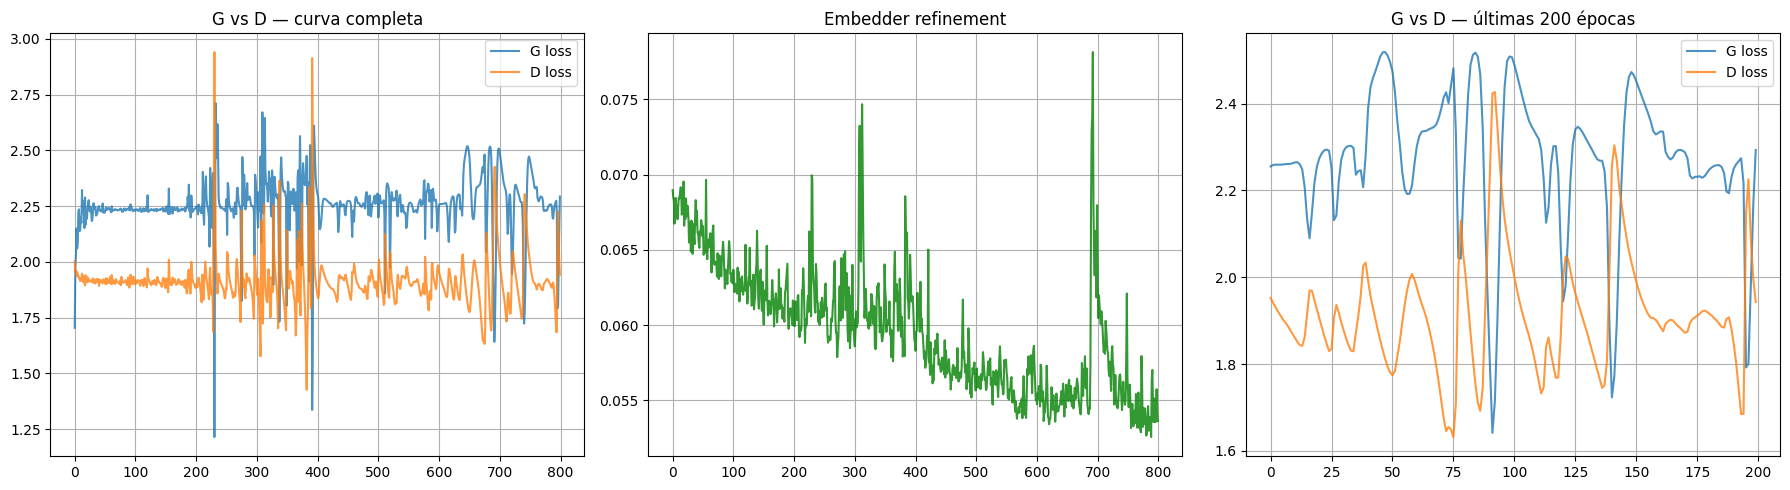

G final: 2.2931 | D final: 1.9428



In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(joint_g_history, label="G loss", alpha=0.8)
axes[0].plot(joint_d_history, label="D loss", alpha=0.8)
axes[0].set_title("G vs D — curva completa")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder refinement")
axes[1].grid(True)

axes[2].plot(joint_g_history[-200:], label="G loss", alpha=0.8)
axes[2].plot(joint_d_history[-200:], label="D loss", alpha=0.8)
axes[2].set_title("G vs D — últimas 200 épocas")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

g_f = joint_g_history[-1]
d_f = joint_d_history[-1]
print(f"G final: {g_f:.4f} | D final: {d_f:.4f}")
print()
if 0.5 < g_f < 2.0 and 0.5 < d_f < 2.0:
    print("✅ Balance adversarial OK — G y D en zona competitiva")
elif d_f < 0.2:
    print("⚠️  Discriminador dominante — considera reducir d_optimizer lr")
elif g_f > 3.0:
    print("❌ Generador colapsado — el discriminador es demasiado fuerte")
    print("   Prueba: aumentar threshold de D a 0.2, o reducir num_layers del discriminador a 2")


## Generación de ventanas sintéticas (continuas)


In [23]:
n_synth = len(train_cont_windows)
synthetic_cont_list = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end   = min(start + 256, n_synth)
        z     = random_z(end - start, seq_len, latent_dim, device)
        e_hat = generator(z)
        h_hat = supervisor(e_hat)
        x_hat = recovery(h_hat).cpu().numpy()
        synthetic_cont_list.append(x_hat)

synthetic_cont_scaled = np.concatenate(synthetic_cont_list, axis=0)

print(f"Synthetic cont windows: {synthetic_cont_scaled.shape}")
print(f"Min/Max: {synthetic_cont_scaled.min():.4f} / {synthetic_cont_scaled.max():.4f}")


Synthetic cont windows: (3784, 60, 23)
Min/Max: 0.0000 / 0.9982


## Síntesis de variables discretas (muestreo empírico)

Las discretas se sintetizan muestreando de la distribución empírica del  
conjunto de entrenamiento. Para cada ventana y cada timestep, se asigna  
un valor discreto proporcional a la frecuencia observada en los datos reales.  
Esto preserva la distribución marginal de cada variable de control.


In [24]:
def synthesize_discrete_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    """
    Genera ventanas discretas muestreando de la distribución empírica.
    Modela correlación temporal simple: cada timestep tiene p=0.95 de
    mantener el valor anterior (para simular que las válvulas no cambian
    en cada segundo).
    """
    rng = np.random.default_rng(seed)
    windows = []

    for _ in range(n_windows):
        window = np.zeros((window_size, len(discrete_cols)), dtype=np.float32)

        for j, col in enumerate(discrete_cols):
            emp = disc_empirical[col]
            vals = list(emp.keys())
            probs = list(emp.values())

            # Timestep inicial
            window[0, j] = rng.choice(vals, p=probs)

            # Timesteps siguientes: persistencia con p=0.95
            for t in range(1, window_size):
                if rng.random() < 0.95:
                    window[t, j] = window[t-1, j]  # mantener estado
                else:
                    window[t, j] = rng.choice(vals, p=probs)  # transición

        windows.append(window)

    return np.array(windows, dtype=np.float32)


synthetic_disc_raw = synthesize_discrete_windows(
    n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, seed=SEED
)
print(f"Synthetic discrete windows: {synthetic_disc_raw.shape}")


Synthetic discrete windows: (3784, 60, 26)


## Decodificar escala y preparar para detector


In [25]:
n_cont = len(continuous_cols)

# Continuas: MinMaxScaler⁻¹ → escala física → StandardScaler del detector
synth_flat          = synthetic_cont_scaled.reshape(-1, n_cont)
synthetic_cont_physical = scaler_cont_timegan.inverse_transform(synth_flat).reshape(synthetic_cont_scaled.shape)

synth_phys_flat     = synthetic_cont_physical.reshape(-1, n_cont)
synthetic_cont_for_detector = scaler_cont_detector.transform(synth_phys_flat).reshape(synthetic_cont_scaled.shape)

print("Synthetic cont physical:", synthetic_cont_physical.shape)
print("Synthetic cont for detector:", synthetic_cont_for_detector.shape)


Synthetic cont physical: (3784, 60, 23)
Synthetic cont for detector: (3784, 60, 23)


c:\Users\j.manriquec\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [26]:
def one_hot_encode_discrete_sequence(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        encoded_t = []
        for j, col in enumerate(discrete_cols):
            categories = discrete_value_maps[col]
            onehot = np.zeros(len(categories), dtype=np.float32)
            value = disc_array[t, j]
            if value in categories:
                onehot[categories.index(value)] = 1.0
            encoded_t.extend(onehot)
        rows.append(encoded_t)
    return np.array(rows, dtype=np.float32)

# One-hot para compatibilidad con detector
synthetic_disc_onehot = np.array([
    one_hot_encode_discrete_sequence(synthetic_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synthetic_disc_raw.shape[0])
], dtype=np.float32)

print("Synthetic disc onehot:", synthetic_disc_onehot.shape)


Synthetic disc onehot: (3784, 60, 91)


In [27]:
def summarize_discrete_windows_from_raw(disc_windows_raw, discrete_cols):
    summary_rows = []
    for w in disc_windows_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            values = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(values).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(values[1:] != values[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(values))
            feats[f"{col}__dominance"]   = pd.Series(values).value_counts(normalize=True).iloc[0]
        summary_rows.append(feats)
    return pd.DataFrame(summary_rows)

synthetic_disc_summary = summarize_discrete_windows_from_raw(synthetic_disc_raw, discrete_cols)
print("Synthetic disc summary:", synthetic_disc_summary.shape)


Synthetic disc summary: (3784, 104)


In [28]:
# Formato final para detector
X_synth_cont = np.transpose(synthetic_cont_for_detector, (0, 2, 1)).astype(np.float32)
X_synth_disc = synthetic_disc_summary.values.astype(np.float32)

print("X_synth_cont for detector:", X_synth_cont.shape)
print("X_synth_disc for detector:", X_synth_disc.shape)


X_synth_cont for detector: (3784, 23, 60)
X_synth_disc for detector: (3784, 104)


## Evaluación: PCA, t-SNE y AUC

**Importante**: La comparación PCA/t-SNE debe hacerse SOLO con las continuas,  
porque las discretas sintéticas se generaron por separado (muestreo empírico).  
Comparar las continuas es la evaluación correcta del TimeGAN.


In [29]:
n_plot = min(1000, len(train_cont_windows), len(synthetic_cont_scaled))

rng = np.random.default_rng(SEED)
real_idx  = rng.choice(len(train_cont_windows),     n_plot, replace=False)
synth_idx = rng.choice(len(synthetic_cont_scaled),  n_plot, replace=False)

real_sample  = train_cont_windows[real_idx].reshape(n_plot, -1)      # (N, 23*60)
synth_sample = synthetic_cont_scaled[synth_idx].reshape(n_plot, -1)  # (N, 23*60)

print(f"Evaluando {n_plot} muestras reales vs {n_plot} sintéticas")
print(f"Dimensión por muestra: {real_sample.shape[1]} (continuas solamente)")


Evaluando 1000 muestras reales vs 1000 sintéticas
Dimensión por muestra: 1380 (continuas solamente)


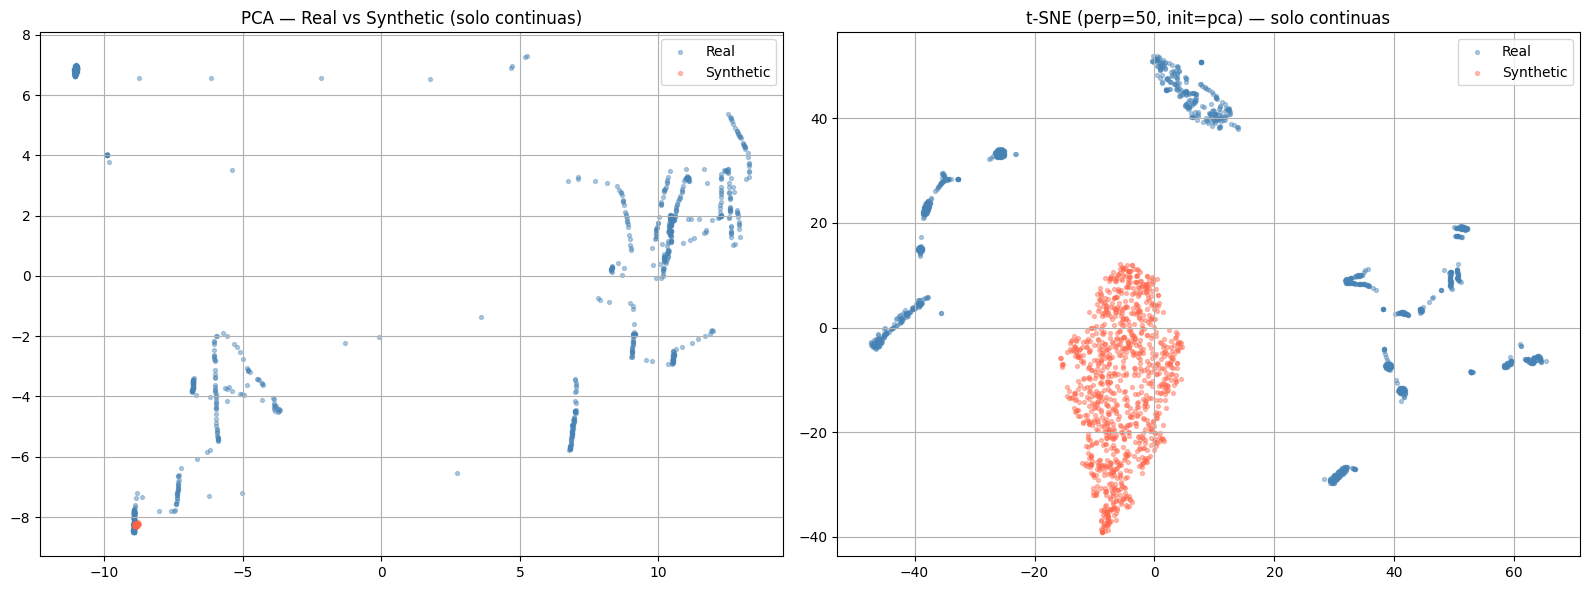

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA
pca = PCA(n_components=2, random_state=SEED)
pca_real  = pca.fit_transform(real_sample)
pca_synth = pca.transform(synth_sample)

axes[0].scatter(pca_real[:, 0],  pca_real[:, 1],  alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(pca_synth[:, 0], pca_synth[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — Real vs Synthetic (solo continuas)")
axes[0].legend()
axes[0].grid(True)

# t-SNE con PCA preprocessing
n_pca_pre = min(50, real_sample.shape[1])
pca_pre   = PCA(n_components=n_pca_pre, random_state=SEED)
combined  = pca_pre.fit_transform(np.vstack([real_sample, synth_sample]))

perp = min(50, n_plot // 5)
tsne = TSNE(n_components=2, random_state=SEED, perplexity=perp, max_iter=2000,
            init="pca", learning_rate="auto")
tsne_out = tsne.fit_transform(combined)

axes[1].scatter(tsne_out[:n_plot, 0], tsne_out[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tsne_out[n_plot:, 0], tsne_out[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp}, init=pca) — solo continuas")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("tsne_v3.png", dpi=150, bbox_inches="tight")
plt.show()


In [32]:
X_all = np.vstack([real_sample, synth_sample])
y_all = np.array([0] * n_plot + [1] * n_plot)

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all)

clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 50)
print("Métrica de discriminabilidad (solo continuas)")
print(f"  AUC = {auc:.4f}")
if auc < 0.6:
    print("  ✅  < 0.60 — Datos sintéticos de alta calidad")
elif auc < 0.75:
    print("  ⚠️  0.60–0.75 — Calidad aceptable para tesis")
else:
    print("  ❌  > 0.75 — Modelo aún colapsado")
    print("  → Revisar curvas G/D. Si D sigue dominando, bajar d_lr a 1e-5.")
print("=" * 50)

# Estadísticas de distribución
mean_diff = np.abs(real_sample.mean(axis=0) - synth_sample.mean(axis=0)).mean()
std_diff  = np.abs(real_sample.std(axis=0)  - synth_sample.std(axis=0)).mean()
print(f"\nDiferencia media de medias: {mean_diff:.4f}")
print(f"Diferencia media de stds:   {std_diff:.4f}")


Métrica de discriminabilidad (solo continuas)
  AUC = 1.0000
  ❌  > 0.75 — Modelo aún colapsado
  → Revisar curvas G/D. Si D sigue dominando, bajar d_lr a 1e-5.

Diferencia media de medias: 0.2763
Diferencia media de stds:   0.3173


## Guardado de artefactos


In [33]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

torch.save(embedder.state_dict(),      TIMEGAN_MODEL_DIR / "embedder.pt")
torch.save(recovery.state_dict(),      TIMEGAN_MODEL_DIR / "recovery.pt")
torch.save(generator.state_dict(),     TIMEGAN_MODEL_DIR / "generator.pt")
torch.save(supervisor.state_dict(),    TIMEGAN_MODEL_DIR / "supervisor.pt")
torch.save(discriminator.state_dict(), TIMEGAN_MODEL_DIR / "discriminator.pt")

joblib.dump(scaler_cont_timegan,  PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_cont_minmax.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_cont_detector.pkl")

with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k, vs in discrete_value_maps.items()}, f, indent=4)

with open(TIMEGAN_MODEL_DIR / "disc_empirical.json", "w") as f:
    json.dump({k: {str(kk): float(vv) for kk, vv in v.items()} for k, v in disc_empirical.items()}, f, indent=4)

timegan_config = {
    "version": "v3",
    "aligned_detector": "conv1d_hybrid_ae",
    "continuous_cols": continuous_cols,
    "discrete_cols": discrete_cols,
    "feature_cols": feature_cols,
    "window_size": WINDOW_SIZE,
    "stride_detector": STRIDE_DETECTOR,
    "stride_timegan": TIMEGAN_STRIDE,
    "warmup": WARMUP,
    "seed": SEED,
    "feature_dim_timegan": feature_dim,
    "discrete_synthesis": "empirical_sampling",
    "hidden_dim": hidden_dim,
    "latent_dim": latent_dim,
    "num_layers": num_layers,
    "epochs_embedder": epochs_embedder,
    "epochs_supervisor": epochs_supervisor,
    "epochs_joint": epochs_joint,
    "batch_size": BATCH_SIZE,
    "gamma": gamma, "eta": eta,
    "lambda_r": lambda_r, "lambda_s": lambda_s, "lambda_m": lambda_m,
    "train_windows": len(train_cont_windows),
    "synthetic_windows": len(synthetic_cont_scaled),
    "auc_discriminability": float(auc),
}

with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f:
    json.dump(timegan_config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_scaled.npy",         synthetic_cont_scaled)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_physical.npy",       synthetic_cont_physical)
np.save(TIMEGAN_MODEL_DIR / "synthetic_cont_for_detector.npy",   synthetic_cont_for_detector)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_raw.npy",            synthetic_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synthetic_disc_onehot.npy",         synthetic_disc_onehot)
synthetic_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synthetic_disc_summary.csv", index=False)

pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history,
    "d_loss": joint_d_history,
    "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅ Artefactos guardados en:", TIMEGAN_MODEL_DIR.resolve())


✅ Artefactos guardados en: C:\Users\j.manriquec\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
